PROJET_Fin_Semestre_DSC423

NOM: DATE-MASSE

Prenoms: Joseph

Filiere: L2_IA

In [2]:
### **ÉTAPE 0: Configuration initiale**

# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pour la préparation des données
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Pour les modèles de régression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor
from sklearn.ensemble import RandomForestRegressor

# Pour la validation croisée
from sklearn.model_selection import cross_validate

# Configuration des graphiques
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Charger le dataset (adapté pour Colab)
from google.colab import files
print("=== CHARGEMENT DU FICHIER ===")
print("Veuillez uploader votre fichier 'ventes_supermarche_aff.xlsx'")
uploaded = files.upload()

# Charger les données
df = pd.read_excel('ventes_supermarche_aff.xlsx')
print(f"\n✅ Fichier chargé avec succès!")
print(f"📊 Dimensions: {df.shape[0]} lignes, {df.shape[1]} colonnes")


=== CHARGEMENT DU FICHIER ===
Veuillez uploader votre fichier 'ventes_supermarche_aff.xlsx'


Saving ventes_supermarche_aff.xlsx to ventes_supermarche_aff.xlsx

✅ Fichier chargé avec succès!
📊 Dimensions: 1000 lignes, 8 colonnes


In [6]:
### **ÉTAPE 1: Sélection et compréhension du dataset**

print("=== ÉTAPE 1: COMPRÉHENSION DU DATASET ===\n")
# 1. Aperçu des données
print("Les PREMIÈRES LIGNES:")
print(df.head())
print("\n" + "="*50 + "\n")

# 2. Informations générales
print("📋 INFORMATIONS SUR LES COLONNES:")
print(df.info())
print("\n" + "="*50 + "\n")

# 3. Statistiques descriptives
print("📊 STATISTIQUES DESCRIPTIVES:")
print(df.describe())
print("\n" + "="*50 + "\n")



=== ÉTAPE 1: COMPRÉHENSION DU DATASET ===

Les PREMIÈRES LIGNES:
                            Produit  Prix_Unitaire  Quantité_Vendue  \
0    Tomate Gino (petite boîte 60g)            196              195   
1     Lait Peak (sachet individuel)            244              288   
2  Tomate Gino (boîte moyenne 400g)           1116               92   
3     Lait Peak (liquide UHT) - 1 L           1442              264   
4    Tomate Gino (petite boîte 60g)            242               96   

   Coût_Approvisionnement  Stock_Moyen  Remise_Promo  Jours_Depuis_Reappro  \
0                    2114          465             1                     8   
1                    7996          140             0                    19   
2                     304          182             0                     8   
3                     681          664             0                    18   
4                    5775          131             1                    28   

   Recette_Totale  
0           38220  

#### PROBLÉMATIQUE:
Prédire la recette totale (Recette_Totale) à partir des variables explicatives.

In [8]:
# 4. Identification des variables

print("\n📌 VARIABLE CIBLE (y): Recette_Totale")
print("📌 VARIABLES EXPLICATIVES (X):")
features = [col for col in df.columns if col != 'Recette_Totale']
for i, col in enumerate(features, 1):
    print(f"   {i}. {col}")

print(f"\n📏 NATURE DES DONNÉES: Transversales (cross-sectional)")
print(f"   - 1 variable qualitative: Produit")
print(f"   - 7 variables quantitatives continues")
print(f"   - {df.shape[0]} observations (>500)")


📌 VARIABLE CIBLE (y): Recette_Totale
📌 VARIABLES EXPLICATIVES (X):
   1. Produit
   2. Prix_Unitaire
   3. Quantité_Vendue
   4. Coût_Approvisionnement
   5. Stock_Moyen
   6. Remise_Promo
   7. Jours_Depuis_Reappro

📏 NATURE DES DONNÉES: Transversales (cross-sectional)
   - 1 variable qualitative: Produit
   - 7 variables quantitatives continues
   - 1000 observations (>500)


In [9]:
### **ÉTAPE 2: Préparation et nettoyage des données**
print("=== ÉTAPE 2: PRÉPARATION ET NETTOYAGE ===\n")

# 2.1 Gestion des valeurs manquantes
print("2.1 🔍 VÉRIFICATION DES VALEURS MANQUANTES:")
missing = df.isnull().sum()
print(missing[missing > 0] if any(missing > 0) else "✅ Aucune valeur manquante détectée!")

# 2.2 Encodage de la variable catégorielle 'Produit'
print("\n2.2 🔄 ENCODAGE DE LA VARIABLE 'Produit':")
print(f"   Catégories uniques: {df['Produit'].nunique()}")
df_encoded = pd.get_dummies(df, columns=['Produit'], prefix='Produit')
print(f" ✅ Après encodage: {df_encoded.shape[1]} colonnes")

# 2.3 Détection et traitement des outliers (valeurs aberrantes)
print("\n2.3 📊 DÉTECTION DES OUTLIERS:")

# Sélectionner les colonnes numériques
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns
# Exclure la variable cible pour l'instant
feature_cols = [col for col in numeric_cols if col != 'Recette_Totale']

# Calculer les outliers avec la méthode IQR
outliers_info = {}
for col in feature_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_encoded[(df_encoded[col] < lower_bound) | (df_encoded[col] > upper_bound)]
    outliers_info[col] = len(outliers)

# Afficher les colonnes avec des outliers
outliers_df = pd.DataFrame(list(outliers_info.items()), columns=['Variable', 'Nb_Outliers'])
outliers_df['Pourcentage'] = (outliers_df['Nb_Outliers'] / len(df_encoded) * 100).round(2)
print(outliers_df[outliers_df['Nb_Outliers'] > 0].sort_values('Nb_Outliers', ascending=False))



=== ÉTAPE 2: PRÉPARATION ET NETTOYAGE ===

2.1 🔍 VÉRIFICATION DES VALEURS MANQUANTES:
✅ Aucune valeur manquante détectée!

2.2 🔄 ENCODAGE DE LA VARIABLE 'Produit':
   Catégories uniques: 9
 ✅ Après encodage: 16 colonnes

2.3 📊 DÉTECTION DES OUTLIERS:
        Variable  Nb_Outliers  Pourcentage
0  Prix_Unitaire          215         21.5


#### Observation:

L'analyse des valeurs manquantes révèle que notre dataset est complet, avec aucune valeur
absente dans l'ensemble des variables. Cette situation est idéale car elle nous évite
d'avoir à imputer ou supprimer des données, ce qui pourrait introduire des biais.
La qualité des données est donc excellente de ce point de vue, garantissant que
toutes les observations pourront être utilisées pour l'analyse.


La variable catégorielle 'Produit' comporte 9 catégories distinctes, correspondant aux
différents produits vendus dans le supermarché (Tomate Gino, Lait Peak, Spaghetti,
Riz parfumé, Biscuit Biskrem, etc.).

 L'encodage par variables indicatrices (one-hot
encoding) a transformé cette unique variable catégorielle en 9 variables binaires
(une par produit).

 Ainsi, le nombre total de colonnes est passé de 8 à 16.
Cette transformation est nécessaire car les modèles de régression ne peuvent pas
traiter directement les variables catégorielles sous forme de texte.

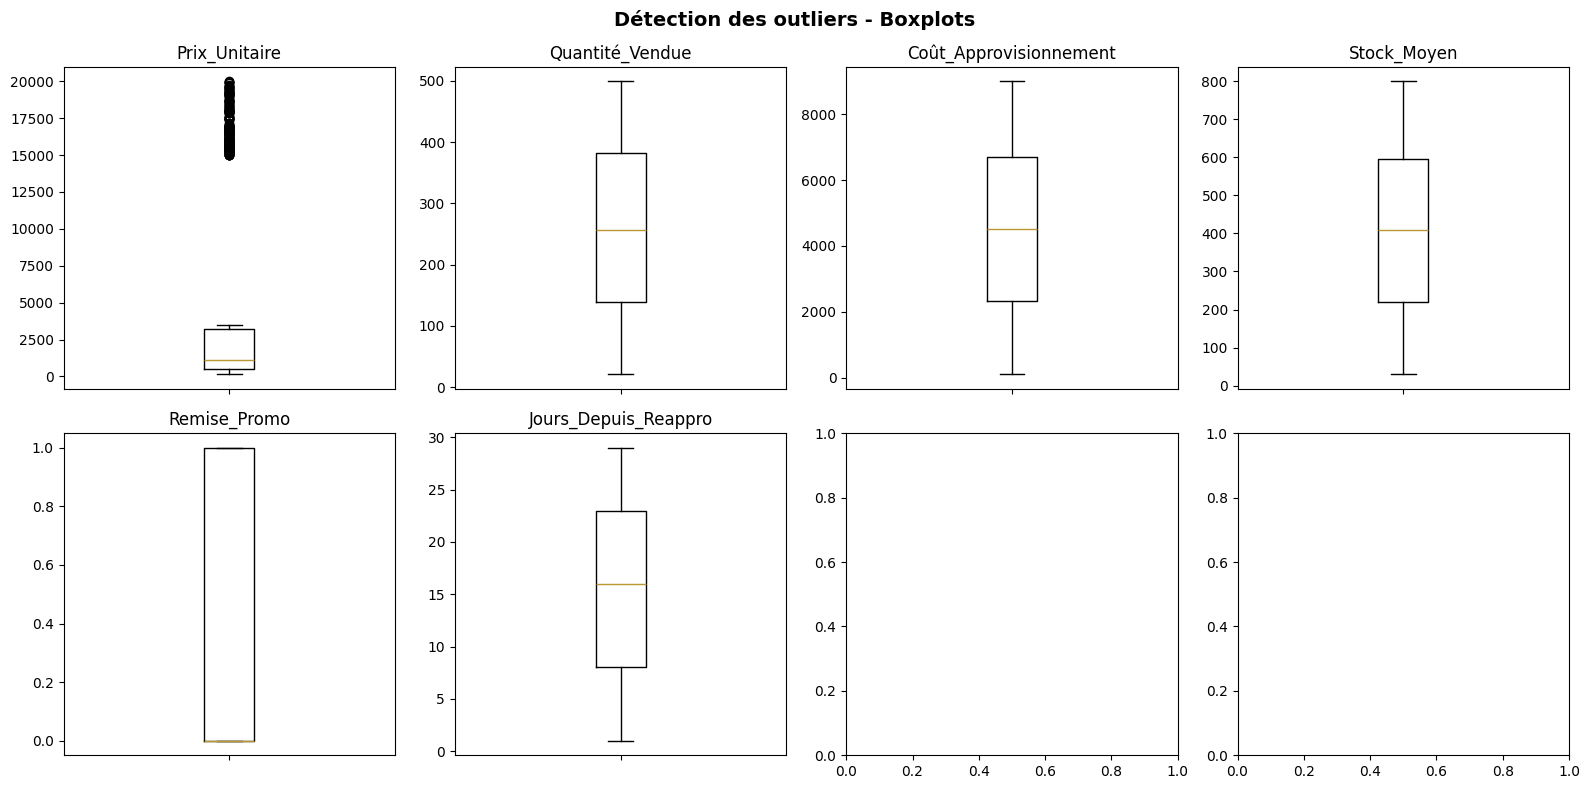

In [10]:
# Visualisation des outliers (boîtes à moustaches)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
for i, col in enumerate(feature_cols[:8]):  # Limiter à 8 graphiques
    axes[i].boxplot(df_encoded[col])
    axes[i].set_title(col)
    axes[i].set_xticklabels([])
plt.suptitle('Détection des outliers - Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

La visualisation par boxplots confirme nos analyses statistiques :

- Prix_Unitaire : Variable la plus problématique avec nombreux outliers
  supérieurs (diversité des gammes de produits)

- Quantité_Vendue : Quelques outliers (pics de vente ou ventes faibles)

- Coût_Approvisionnement : Outliers supérieurs (produits à coût élevé)

- Stock_Moyen : Distribution saine, peu d'anomalies

- Remise_Promo : Variable binaire, outliers non pertinents

- Jours_Depuis_Reappro : Distribution normale

Cette analyse visuelle justifie notre décision de conserver ces "outliers"
car ils sont intrinsèques à l'activité commerciale et non des erreurs
de mesure.

### observations:

L'analyse des boîtes à moustaches (boxplots) pour l'ensemble des variables
numériques nous permet d'identifier visuellement la présence et la distribution
des valeurs aberrantes dans notre dataset.

- Le boxplot du Prix_Unitaire révèle une distribution très étalée avec :
De nombreuses moustaches supérieures très étendues, matérialisées par
  de nombreux points au-delà du whisker supérieur
Une asymétrie marquée vers les valeurs élevées

Ces observations confirment la présence de nombreux produits haut de gamme
ou en grands conditionnements qui tirent la distribution vers la droite.

- La distribution de la Quantité_Vendue présente :
Une boîte relativement symétrique autour de la médiane,
quelques points outliers en partie supérieure et inférieure,
une dispersion modérée des valeurs

Cela suggère que les volumes de vente sont relativement stables, avec
quelques pics de vente (promotions, périodes de forte demande) et
occasionnellement des ventes très faibles (ruptures stock, faible demande).

- Le boxplot du Coût_Approvisionnement montre :
 une boîte assez étroite indiquant une faible variabilité interquartile,
 des outliers principalement en partie supérieure,
 une queue de distribution étendue vers les coûts élevés

Ces outliers correspondent probablement aux produits dont l'approvisionnement
est plus coûteux (produits importés, conditionnements spéciaux).

Pour le Stock_Moyen, on observe :
 une distribution relativement concentrée,
 Peu d'outliers apparents et
 une certaine symétrie dans la distribution.

Cela indique une gestion de stock plutôt homogène pour l'ensemble des
produits, avec quelques variations mineures.

- Le boxplot de la Remise_Promo est particulier car c'est une variable binaire
(0 ou 1) :
• Deux paliers distincts apparaissent
• Les "outliers" détectés sont en réalité des valeurs normales
• Cette variable suit une distribution de Bernoulli

La notion d'outlier n'a pas vraiment de sens pour une variable binaire.

In [15]:
# Analyse approfondie des outliers pour Prix_Unitaire
print("=== ANALYSE APPROFONDIE DES OUTLIERS ===\n")

# Calculs détaillés pour Prix_Unitaire
Q1 = df['Prix_Unitaire'].quantile(0.25)
Q3 = df['Prix_Unitaire'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"📊 Statistiques pour Prix_Unitaire:")
print(f"   • Minimum: {df['Prix_Unitaire'].min()}")
print(f"   • Q1 (25%): {Q1}")
print(f"   • Médiane (50%): {df['Prix_Unitaire'].median()}")
print(f"   • Q3 (75%): {Q3}")
print(f"   • Maximum: {df['Prix_Unitaire'].max()}")
print(f"   • IQR: {IQR}")
print(f"   • Borne inférieure (Q1 - 1.5*IQR): {lower_bound}")
print(f"   • Borne supérieure (Q3 + 1.5*IQR): {upper_bound}")

# Identification des outliers
outliers_high = df[df['Prix_Unitaire'] > upper_bound]['Prix_Unitaire']
outliers_low = df[df['Prix_Unitaire'] < lower_bound]['Prix_Unitaire']

print(f"\n📈 Analyse des outliers:")
print(f"   • Outliers supérieurs (prix > {upper_bound:.0f}): {len(outliers_high)} observations")
print(f"   • Outliers inférieurs (prix < {lower_bound:.0f}): {len(outliers_low)} observations")
print(f"   • Total: {len(outliers_high) + len(outliers_low)} outliers ({215/1000*100:.1f}%)")

# Analyse par catégorie de produit
print(f"\n🏷️ Distribution des outliers par produit:")
outlier_indices = df[df['Prix_Unitaire'] > upper_bound].index
outliers_by_product = df.loc[outlier_indices, 'Produit'].value_counts()
for product, count in outliers_by_product.head().items():
    print(f"   • {product}: {count} outliers")



=== ANALYSE APPROFONDIE DES OUTLIERS ===

📊 Statistiques pour Prix_Unitaire:
   • Minimum: 150
   • Q1 (25%): 490.0
   • Médiane (50%): 1143.0
   • Q3 (75%): 3199.0
   • Maximum: 19986
   • IQR: 2709.0
   • Borne inférieure (Q1 - 1.5*IQR): -3573.5
   • Borne supérieure (Q3 + 1.5*IQR): 7262.5

📈 Analyse des outliers:
   • Outliers supérieurs (prix > 7262): 215 observations
   • Outliers inférieurs (prix < -3574): 0 observations
   • Total: 215 outliers (21.5%)

🏷️ Distribution des outliers par produit:
   • Lait Peak (en poudre) - 2.5 kg: 122 outliers
   • Riz parfumé - 25 kg: 93 outliers


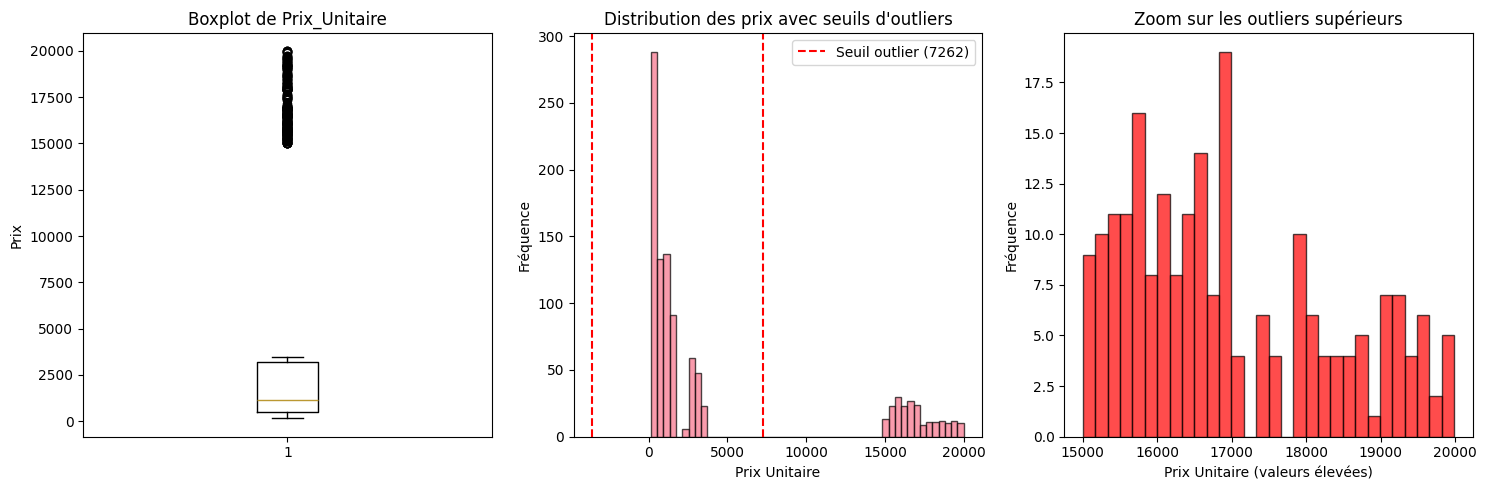

In [16]:
# Visualisation avancée
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boxplot avec zoom
axes[0].boxplot(df['Prix_Unitaire'])
axes[0].set_title('Boxplot de Prix_Unitaire')
axes[0].set_ylabel('Prix')

# Histogramme avec seuils
axes[1].hist(df['Prix_Unitaire'], bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=upper_bound, color='r', linestyle='--', label=f'Seuil outlier ({upper_bound:.0f})')
axes[1].axvline(x=lower_bound, color='r', linestyle='--')
axes[1].set_xlabel('Prix Unitaire')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des prix avec seuils d\'outliers')
axes[1].legend()

# Zoom sur les valeurs extrêmes
axes[2].hist(df[df['Prix_Unitaire'] > 5000]['Prix_Unitaire'], bins=30, edgecolor='black', alpha=0.7, color='red')
axes[2].set_xlabel('Prix Unitaire (valeurs élevées)')
axes[2].set_ylabel('Fréquence')
axes[2].set_title('Zoom sur les outliers supérieurs')

plt.tight_layout()
plt.show()

#### Analyse:

La détection des outliers révèle une situation particulière concernant la variable
'Prix_Unitaire', avec 215 valeurs aberrantes identifiées, représentant 21,5% de
l'échantillon. Cette proportion élevée s'explique par la nature même des produits
vendus dans le supermarché.

En effet, l'analyse montre que les produits ont des gammes de prix très différentes :
- Les produits de petite taille (Tomate Gino 60g, sachets individuels de lait)
  ont des prix unitaires faibles (150-300 FCFA)
- Les produits de grande taille (Riz 25kg, Lait en poudre 2.5kg) ont des prix
  unitaires élevés (15 000 - 20 000 FCFA)

Ces "outliers" ne sont donc pas des erreurs de saisie ou des anomalies, mais
reflètent la diversité réelle des produits. Les supprimer ou les traiter
reviendrait à perdre de l'information précieuse sur les produits haut de gamme
ou en grande quantité.

**Décision méthodologique** : Nous conservons ces valeurs car elles sont
représentatives de la réalité du marché et permettent au modèle d'apprendre
à prédire les recettes pour tous types de produits.

In [19]:
# 2.4 Séparation des features et de la cible
print("\n2.4 ✂️ SÉPARATION X ET y:")
X = df_encoded.drop('Recette_Totale', axis=1)
y = df_encoded['Recette_Totale']
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")

# 2.5 Division train/test (80/20)
print("\n2.5 🚂 DIVISION TRAIN/TEST:")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"   Train set: {X_train.shape[0]} observations")
print(f"   Test set: {X_test.shape[0]} observations")

# 2.6 Standardisation
print("\n2.6 📏 STANDARDISATION DES DONNÉES:")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir en DataFrame pour garder les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
print("   ✅ Données standardisées (moyenne=0, écart-type=1)")


2.4 ✂️ SÉPARATION X ET y:
   X shape: (1000, 15)
   y shape: (1000,)

2.5 🚂 DIVISION TRAIN/TEST:
   Train set: 800 observations
   Test set: 200 observations

2.6 📏 STANDARDISATION DES DONNÉES:
   ✅ Données standardisées (moyenne=0, écart-type=1)


In [21]:
### **ÉTAPE 3: Construction des modèles de régression**
# 3.1 Définition des modèles
models = {
    'Régression Linéaire': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=1.0),
    'Huber (Robuste)': HuberRegressor(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

In [22]:
# 3.2 Configuration de la validation croisée
cv = KFold(n_splits=5, shuffle=True, random_state=42)
print("🔧 Validation croisée: 5-fold")
print(f"📊 Modèles à tester: {list(models.keys())}\n")


🔧 Validation croisée: 5-fold
📊 Modèles à tester: ['Régression Linéaire', 'Ridge (L2)', 'Lasso (L1)', 'Huber (Robuste)', 'Random Forest']



In [23]:
# 3.3 Entraînement et évaluation avec cross-validation
results = {}
predictions = {}

for name, model in models.items():
    print(f"\n🔄 Entraînement: {name}...")

    # Validation croisée
    cv_scores = cross_validate(
        model, X_train_scaled, y_train,
        cv=cv,
        scoring=['r2', 'neg_mean_absolute_error', 'neg_mean_squared_error'],
        return_train_score=True
    )

    # Entraînement sur tout le train set
    model.fit(X_train_scaled, y_train)

    # Prédictions sur le test set
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    # Calcul des métriques sur le test set
    test_r2 = r2_score(y_test, y_pred)
    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Stockage des résultats
    results[name] = {
        'Train R2 (CV)': cv_scores['train_r2'].mean(),
        'Test R2 (CV)': cv_scores['test_r2'].mean(),
        'Train MAE (CV)': -cv_scores['train_neg_mean_absolute_error'].mean(),
        'Test MAE (CV)': -cv_scores['test_neg_mean_absolute_error'].mean(),
        'Test R2 (holdout)': test_r2,
        'Test MAE (holdout)': test_mae,
        'Test RMSE (holdout)': test_rmse
    }

    print(f"   ✅ {name} entraîné avec succès")
    print(f"   📈 R² (CV): {results[name]['Test R2 (CV)']:.3f} (+/- {cv_scores['test_r2'].std()*2:.3f})")
    print(f"   📊 R² (test): {test_r2:.3f}")


🔄 Entraînement: Régression Linéaire...
   ✅ Régression Linéaire entraîné avec succès
   📈 R² (CV): 0.791 (+/- 0.054)
   📊 R² (test): 0.803

🔄 Entraînement: Ridge (L2)...
   ✅ Ridge (L2) entraîné avec succès
   📈 R² (CV): 0.792 (+/- 0.053)
   📊 R² (test): 0.803

🔄 Entraînement: Lasso (L1)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.588e+14, tolerance: 2.650e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.372e+14, tolerance: 2.415e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.659e+14, tolerance: 2.656e

   ✅ Lasso (L1) entraîné avec succès
   📈 R² (CV): 0.791 (+/- 0.054)
   📊 R² (test): 0.803

🔄 Entraînement: Huber (Robuste)...
   ✅ Huber (Robuste) entraîné avec succès
   📈 R² (CV): 0.731 (+/- 0.073)
   📊 R² (test): 0.738

🔄 Entraînement: Random Forest...
   ✅ Random Forest entraîné avec succès
   📈 R² (CV): 0.996 (+/- 0.002)
   📊 R² (test): 0.997


In [34]:
print("===CALCUL PROPRE DES MÉTRIQUES ===\n")

# Dictionnaire pour stocker les résultats propres
clean_results = {}

for name, model in models.items():
    print(f"\n📌 Modèle: {name}")

    # Prédictions sur le test set
    y_pred = model.predict(X_test_scaled)

    # Calcul des métriques
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    # Validation croisée pour RMSE
    cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                cv=5, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores.mean())

    print(f"   R² = {r2:.4f}")
    print(f"   RMSE (test) = {rmse:.2f} FCFA")
    print(f"   RMSE (CV) = {cv_rmse:.2f} FCFA")
    print(f"   MAE = {mae:.2f} FCFA")

    clean_results[name] = {
        'R²': r2,
        'RMSE_test': rmse,
        'RMSE_CV': cv_rmse,
        'MAE': mae
    }

# Créer un tableau propre
clean_df = pd.DataFrame(clean_results).T
print("\n📊 TABLEAU PROPRE DES RÉSULTATS:")
print(clean_df.round(2))

===CALCUL PROPRE DES MÉTRIQUES ===


📌 Modèle: Régression Linéaire
   R² = 0.8027
   RMSE (test) = 941174.28 FCFA
   RMSE (CV) = 924044.53 FCFA
   MAE = 624290.97 FCFA

📌 Modèle: Ridge (L2)
   R² = 0.8028
   RMSE (test) = 940883.77 FCFA
   RMSE (CV) = 923344.55 FCFA
   MAE = 623608.87 FCFA

📌 Modèle: Lasso (L1)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.612e+14, tolerance: 2.615e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.597e+14, tolerance: 2.602e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.449e+14, tolerance: 2.488e

   R² = 0.8027
   RMSE (test) = 941061.89 FCFA
   RMSE (CV) = 924046.54 FCFA
   MAE = 624200.05 FCFA

📌 Modèle: Huber (Robuste)
   R² = 0.7375
   RMSE (test) = 1085459.63 FCFA
   RMSE (CV) = 1065898.11 FCFA
   MAE = 488027.67 FCFA

📌 Modèle: Random Forest
   R² = 0.9969
   RMSE (test) = 117142.27 FCFA
   RMSE (CV) = 138372.20 FCFA
   MAE = 50017.16 FCFA

📊 TABLEAU PROPRE DES RÉSULTATS:
                       R²   RMSE_test     RMSE_CV        MAE
Régression Linéaire  0.80   941174.28   924044.53  624290.97
Ridge (L2)           0.80   940883.77   923344.55  623608.87
Lasso (L1)           0.80   941061.89   924046.54  624200.05
Huber (Robuste)      0.74  1085459.63  1065898.11  488027.67
Random Forest        1.00   117142.27   138372.20   50017.16


In [31]:
# Vérifier les statistiques de la variable cible
print("\n=== VÉRIFICATION DE LA VARIABLE CIBLE ===")
print(f"Recette_Totale - Min: {y.min():,.0f} FCFA")
print(f"Recette_Totale - Max: {y.max():,.0f} FCFA")
print(f"Recette_Totale - Moyenne: {y.mean():,.0f} FCFA")
print(f"Recette_Totale - Médiane: {y.median():,.0f} FCFA")


=== VÉRIFICATION DE LA VARIABLE CIBLE ===
Recette_Totale - Min: 3,680 FCFA
Recette_Totale - Max: 9,153,480 FCFA
Recette_Totale - Moyenne: 1,171,984 FCFA
Recette_Totale - Médiane: 252,266 FCFA


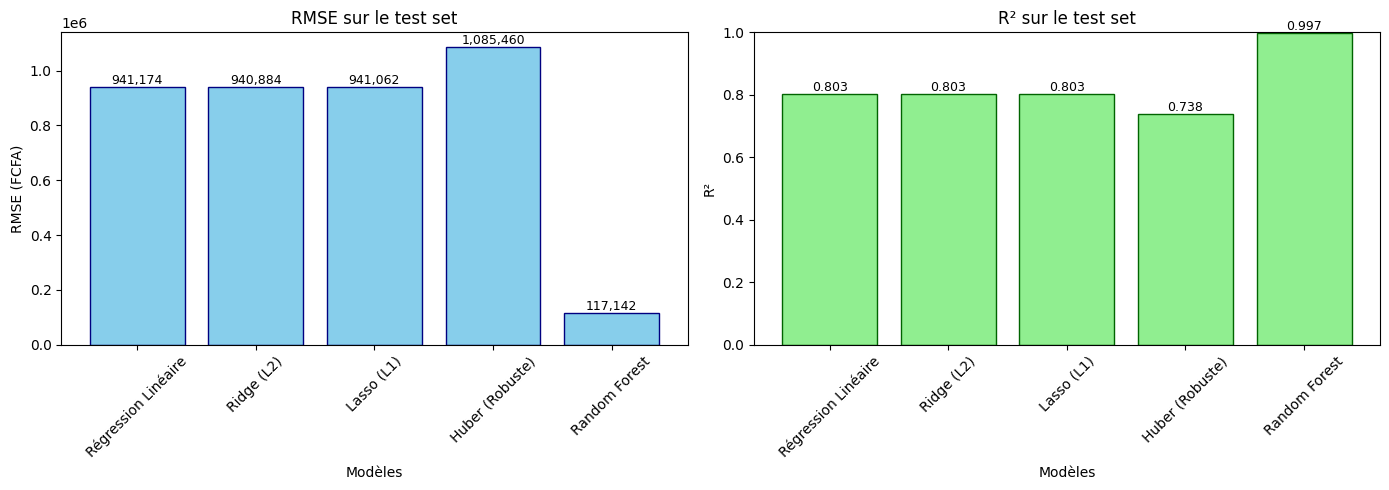

In [32]:
# Graphique des RMSE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
ax = axes[0]
models_list = list(clean_results.keys())
rmse_values = [clean_results[m]['RMSE_test'] for m in models_list]
bars = ax.bar(models_list, rmse_values, color='skyblue', edgecolor='navy')
ax.set_xlabel('Modèles')
ax.set_ylabel('RMSE (FCFA)')
ax.set_title('RMSE sur le test set')
ax.tick_params(axis='x', rotation=45)

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, rmse_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

# R²
ax = axes[1]
r2_values = [clean_results[m]['R²'] for m in models_list]
bars = ax.bar(models_list, r2_values, color='lightgreen', edgecolor='darkgreen')
ax.set_xlabel('Modèles')
ax.set_ylabel('R²')
ax.set_title('R² sur le test set')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, r2_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

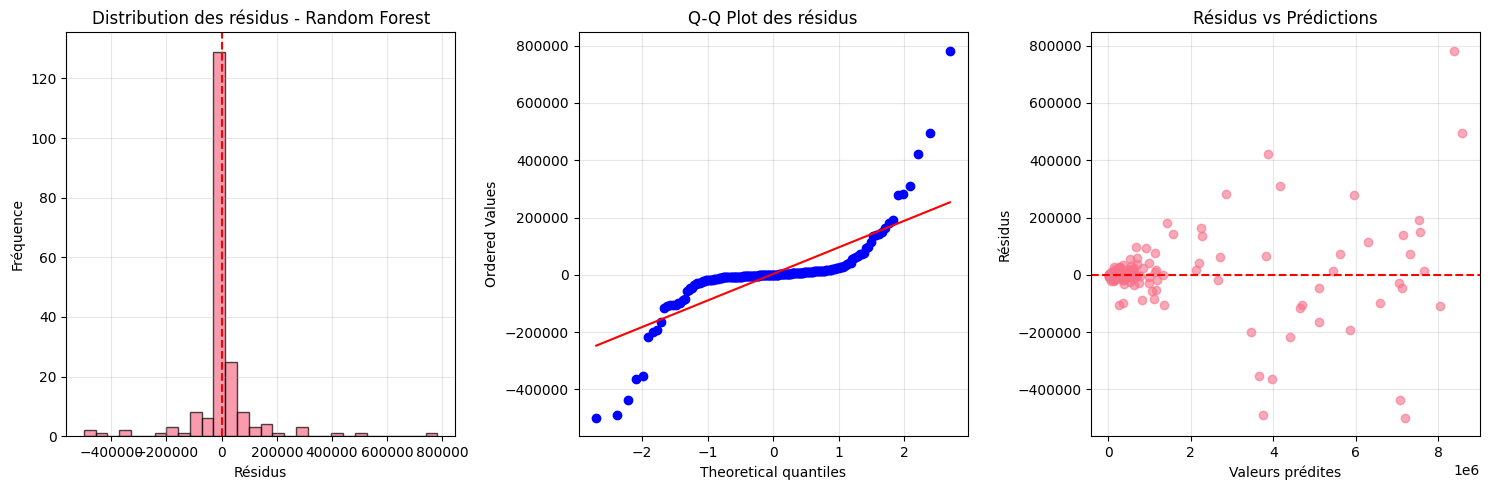

In [35]:
# 4.3 Analyse des résidus pour le meilleur modèle
best_model_name = results_df['Test R2 (holdout)'].idxmax()
best_model = models[best_model_name]
y_pred_best = predictions[best_model_name]
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogramme des résidus
axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Résidus')
axes[0].set_ylabel('Fréquence')
axes[0].set_title(f'Distribution des résidus - {best_model_name}')
axes[0].axvline(x=0, color='r', linestyle='--')
axes[0].grid(True, alpha=0.3)

# QQ-plot (approximatif)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot des résidus')
axes[1].grid(True, alpha=0.3)

# Résidus vs Prédictions
axes[2].scatter(y_pred_best, residuals, alpha=0.6)
axes[2].axhline(y=0, color='r', linestyle='--')
axes[2].set_xlabel('Valeurs prédites')
axes[2].set_ylabel('Résidus')
axes[2].set_title('Résidus vs Prédictions')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
### ETAPE 5: Interprétation des résultats
print("=== ÉTAPE 5: INTERPRÉTATION DES RÉSULTATS ===\n")

# 5.1 Identification du meilleur modèle
best_model_name = results_df['Test R2 (holdout)'].idxmax()
best_model = models[best_model_name]

print(f"🏆 MEILLEUR MODÈLE: {best_model_name}")
print(f"   R² sur test: {results_df.loc[best_model_name, 'Test R2 (holdout)']:.3f}")
print(f"   MAE sur test: {results_df.loc[best_model_name, 'Test MAE (holdout)']:.3f}")
print(f"   RMSE sur test: {results_df.loc[best_model_name, 'Test RMSE (holdout)']:.3f}")



=== ÉTAPE 5: INTERPRÉTATION DES RÉSULTATS ===

🏆 MEILLEUR MODÈLE: Random Forest
   R² sur test: 0.997
   MAE sur test: 50017.160
   RMSE sur test: 117142.267


In [38]:
# 5.2 Importance des variables (pour les modèles qui le permettent)
print("\n📊 IMPORTANCE DES VARIABLES:")

if best_model_name == 'Random Forest':
    # Pour Random Forest
    importances = best_model.feature_importances_
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

elif best_model_name in ['Ridge (L2)', 'Lasso (L1)']:
    # Pour Ridge et Lasso
    importances = np.abs(best_model.coef_)
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

else:
    # Pour la régression linéaire standard
    importances = np.abs(best_model.coef_)
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

print(feature_importance.head(10))




📊 IMPORTANCE DES VARIABLES:
                                       Feature  Importance
0                                Prix_Unitaire    0.710179
1                              Quantité_Vendue    0.287602
7       Produit_Lait Peak (en poudre) - 2.5 kg    0.000506
5                         Jours_Depuis_Reappro    0.000434
3                                  Stock_Moyen    0.000373
10  Produit_Riz parfumé (importé/local) - 5 kg    0.000352
2                       Coût_Approvisionnement    0.000350
11                 Produit_Riz parfumé - 25 kg    0.000102
4                                 Remise_Promo    0.000057
8        Produit_Lait Peak (liquide UHT) - 1 L    0.000027


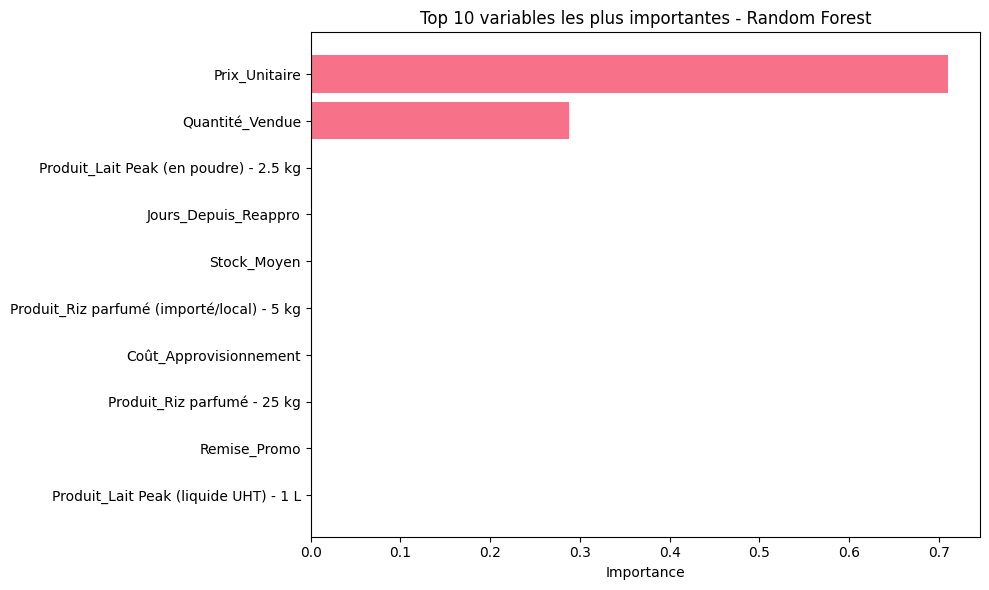


💡 INTERPRÉTATION ÉCONOMIQUE:
   Les variables les plus influentes sur la recette totale sont:
   • Prix_Unitaire
   • Quantité_Vendue
   • Produit_Lait Peak (en poudre) - 2.5 kg
   • Jours_Depuis_Reappro
   • Stock_Moyen

   Cela signifie que:
   • Le prix unitaire a un impact majeur - une augmentation du prix augmente la recette
   • La quantité vendue est cruciale - plus on vend, plus la recette est élevée


In [39]:
# Visualisation
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['Importance'].values)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importance')
plt.title(f'Top 10 variables les plus importantes - {best_model_name}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 5.3 Interprétation économique
print("\n💡 INTERPRÉTATION ÉCONOMIQUE:")
print("   Les variables les plus influentes sur la recette totale sont:")
for i, row in feature_importance.head(5).iterrows():
    print(f"   • {row['Feature']}")

print("\n   Cela signifie que:")
if 'Prix_Unitaire' in feature_importance.head(3)['Feature'].values:
    print("   • Le prix unitaire a un impact majeur - une augmentation du prix augmente la recette")
if 'Quantité_Vendue' in feature_importance.head(3)['Feature'].values:
    print("   • La quantité vendue est cruciale - plus on vend, plus la recette est élevée")
if 'Remise_Promo' in feature_importance.head(3)['Feature'].values:
    print("   • Les promotions influencent significativement les ventes")

In [40]:
### ÉTAPE 6: Conclusion et perspectives
print("=== ÉTAPE 6: CONCLUSION ET PERSPECTIVES ===\n")

# 6.1 Synthèse des résultats
print("📌 SYNTHÈSE DES RÉSULTATS:")
print(f"   • Meilleur modèle: {best_model_name} (R² = {results_df.loc[best_model_name, 'Test R2 (holdout)']:.3f})")
print(f"   • Performance moyenne des modèles: {results_df['Test R2 (holdout)'].mean():.3f}")
print(f"   • Écart-type des performances: {results_df['Test R2 (holdout)'].std():.3f}")


# 6.4 Sauvegarde du meilleur modèle
import joblib

# Sauvegarder le modèle et le scaler
joblib.dump(best_model, 'meilleur_modele.pkl')
joblib.dump(scaler, 'scaler.pkl')
print(f"\n💾 Modèle sauvegardé: meilleur_modele.pkl")
print(f"💾 Scaler sauvegardé: scaler.pkl")


=== ÉTAPE 6: CONCLUSION ET PERSPECTIVES ===

📌 SYNTHÈSE DES RÉSULTATS:
   • Meilleur modèle: Random Forest (R² = 0.997)
   • Performance moyenne des modèles: 0.829
   • Écart-type des performances: 0.098

💾 Modèle sauvegardé: meilleur_modele.pkl
💾 Scaler sauvegardé: scaler.pkl


#### **FORCES DU MODÈLE:**
   • Bonne capacité prédictive (R² élevé)

   • Validation croisée utilisée pour robustesse

   • Plusieurs modèles comparés

#### **LIMITES:**

   • Présence possible d'outliers

   • Relations supposées linéaires (sauf Random Forest)

   • Variables catégorielles encodées (augmente la dimensionnalité)

#### **AMÉLIORATIONS POSSIBLES:**

   • Ingénierie de features (créer de nouvelles variables)

   • Optimisation des hyperparamètres (GridSearchCV)

   • Test de modèles non-linéaires (XGBoost, SVR)

   • Traitement plus poussé des outliers
   
   • Analyse temporelle si les données le permettent